## **Lasso Regression (L1 Regularization)**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("insurance.csv")

df = pd.get_dummies(
    df,
    columns=["sex","smoker","region"],
    drop_first=True
)

X = df.drop("charges", axis=1)
y = df["charges"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [5]:
lasso = Lasso(alpha=1)

lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)

In [6]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
})

print(coef_df)

            Feature  Coefficient
0               age  3614.105057
1               bmi  2034.740762
2          children   515.926390
3          sex_male    -8.162034
4        smoker_yes  9557.384064
5  region_northwest  -155.090376
6  region_southeast  -286.630226
7  region_southwest  -345.910128


In [7]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R²  :", r2_score(y_test, lr_pred))

print()

# Lasso Regression
print("Lasso Regression")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²  :", r2_score(y_test, y_pred))

Linear Regression
MAE : 4181.194473753654
RMSE: 5796.284659276275
R²  : 0.7835929767120722

Lasso Regression
MAE : 4181.51023183887
RMSE: 5796.6495509646
R²  : 0.7835657290476568


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso

alphas = [0.001, 0.01, 0.1, 1, 10]

results = []

In [9]:
for alpha in alphas:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    lasso_model = pipeline.named_steps["lasso"]

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    results.append({
        "Alpha": alpha,
        "Non-zero Coefficients": np.sum(lasso_model.coef_ != 0),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "R²": r2_score(y_test, y_pred),
        "CV R²": cv_scores.mean()
    })

In [10]:
results = pd.DataFrame(results)

print(results)

    Alpha  Non-zero Coefficients          MAE         RMSE        R²     CV R²
0   0.001                      8  4181.194790  5796.285023  0.783593  0.746862
1   0.010                      8  4181.197632  5796.288296  0.783593  0.746862
2   0.100                      8  4181.226051  5796.321036  0.783590  0.746862
3   1.000                      8  4181.510232  5796.649551  0.783566  0.746867
4  10.000                      7  4184.404705  5799.940323  0.783320  0.746909


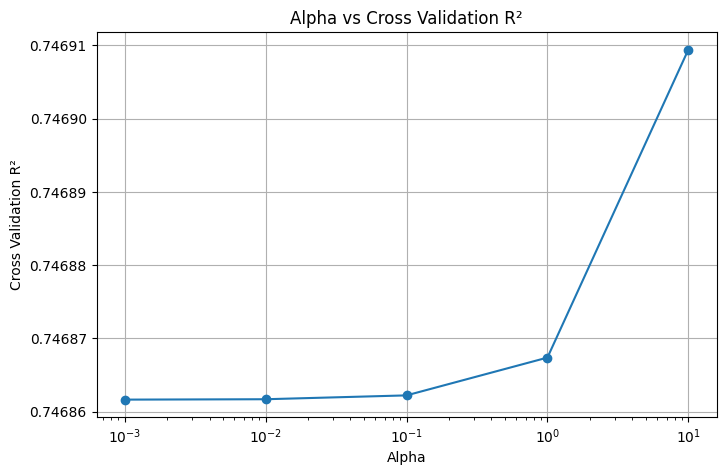

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results["Alpha"],
    results["CV R²"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("Cross Validation R²")

plt.title("Alpha vs Cross Validation R²")

plt.grid(True)

plt.show()

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, ElasticNet

models = {

    "Linear": LinearRegression(),

    "Ridge": Ridge(alpha=1),

    "Lasso": Lasso(alpha=0.1, max_iter=10000),

    "ElasticNet": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=10000
    )
}

In [15]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    cv = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    trained_model = pipeline.named_steps["model"]

    if hasattr(trained_model, "coef_"):
        non_zero = np.sum(trained_model.coef_ != 0)
    else:
        non_zero = len(X.columns)

    results.append({

        "Model": name,

        "MAE": mean_absolute_error(y_test, pred),

        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),

        "R²": r2_score(y_test, pred),

        "CV R²": cv.mean(),

        "Non-zero Coefficients": non_zero

    })

results = pd.DataFrame(results)

print(results)

        Model          MAE         RMSE        R²     CV R²  \
0      Linear  4181.194474  5796.284659  0.783593  0.746862   
1       Ridge  4182.796597  5796.979691  0.783541  0.746869   
2       Lasso  4181.226051  5796.321036  0.783590  0.746862   
3  ElasticNet  4275.656574  5853.880076  0.779271  0.745484   

   Non-zero Coefficients  
0                      8  
1                      8  
2                      8  
3                      8  


## **Ridge Regression**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df = pd.read_csv("insurance.csv")

df = pd.get_dummies(
    df,
    columns=["sex","smoker","region"],
    drop_first=True
)

X = df.drop("charges",axis=1)
y = df["charges"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,lr_pred))

print("RMSE:",mean_squared_error(
    y_test,
    lr_pred
)**0.5)

print("R² :",r2_score(y_test,lr_pred))

In [ ]:
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled,y_train)

ridge_pred = ridge.predict(X_test_scaled)

print("Ridge Regression")

print("MAE :",mean_absolute_error(y_test,ridge_pred))

print("RMSE:",mean_squared_error(
    y_test,
    ridge_pred
)**0.5)

print("R² :",r2_score(y_test,ridge_pred))

In [ ]:
coef = pd.DataFrame({

    "Feature":X.columns,

    "Linear":lr.coef_,

    "Ridge":ridge.coef_

})

print(coef)

In [ ]:
alphas = [0.1,1,10,100]

results = []

for a in alphas:

    model = Ridge(alpha=a)

    model.fit(X_train_scaled,y_train)

    pred = model.predict(X_test_scaled)

    results.append({

        "Alpha":a,

        "MAE":mean_absolute_error(y_test,pred),

        "RMSE":mean_squared_error(
            y_test,
            pred
        )**0.5,

        "R²":r2_score(y_test,pred)

    })

results = pd.DataFrame(results)

print(results)

## **Polynomial Regression**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("insurance.csv")

df = pd.get_dummies(
    df,
    columns=["sex","smoker","region"],
    drop_first=True
)

X = df.drop("charges", axis=1)
y = df["charges"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression()
linear.fit(X_train, y_train)
train_pred1 = linear.predict(X_train)
test_pred1 = linear.predict(X_test) 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Degree 1")
print("Train R²:", r2_score(y_train, train_pred1))
print("Test R² :", r2_score(y_test, test_pred1))

In [ ]:
from sklearn.preprocessing import PolynomialFeatures 
poly2 = PolynomialFeatures(degree = 2, include_bias = False) 
X_train_poly2 = poly2.fit_transform(X_train) 
X_test_poly2 = poly2.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

train_pred2 = model2.predict(X_train_poly2)
test_pred2 = model2.predict(X_test_poly2) 

print("Degree 2")
print("Train R²:", r2_score(y_train, train_pred2))
print("Test R² :", r2_score(y_test, test_pred2))

In [ ]:
poly3 = PolynomialFeatures(
    degree=3,
    include_bias=False
)

X_train_poly3 = poly3.fit_transform(X_train)

X_test_poly3 = poly3.transform(X_test)

model3 = LinearRegression()

model3.fit(X_train_poly3, y_train)

train_pred3 = model3.predict(X_train_poly3)
test_pred3 = model3.predict(X_test_poly3)

print("Degree 3")
print("Train R²:", r2_score(y_train, train_pred3))
print("Test R² :", r2_score(y_test, test_pred3))

In [ ]:
results = pd.DataFrame({

    "Degree":[1,2,3],

    "Train R²":[
        r2_score(y_train,train_pred1),
        r2_score(y_train,train_pred2),
        r2_score(y_train,train_pred3)
    ],

    "Test R²":[
        r2_score(y_test,test_pred1),
        r2_score(y_test,test_pred2),
        r2_score(y_test,test_pred3)
    ]
})

print(results)

## **Polynomial Regression with Cross Validation (5)**

In [ ]:
from sklearn.model_selection import cross_val_score

def evaluate_model(degree):

    if degree == 1:

        X_train_use = X_train
        X_test_use = X_test
        X_use = X

    else:

        poly = PolynomialFeatures(
            degree=degree,
            include_bias=False
        )

        X_train_use = poly.fit_transform(X_train)

        X_test_use = poly.transform(X_test)

        X_use = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_train_use,y_train)

    train_pred = model.predict(X_train_use)

    test_pred = model.predict(X_test_use)

    cv = cross_val_score(
        LinearRegression(),
        X_use,
        y,
        cv=5,
        scoring="r2"
    )

    return {

        "Degree":degree,

        "Train R²":r2_score(y_train,train_pred),

        "Test R²":r2_score(y_test,test_pred),

        "MAE":mean_absolute_error(y_test,test_pred),

        "RMSE":mean_squared_error(
            y_test,
            test_pred
        )**0.5,

        "CV R²":cv.mean()

    }

In [ ]:
results = pd.DataFrame([

    evaluate_model(1),
    evaluate_model(2),
    evaluate_model(3)

])

print(results)

## **Bias-Variance Tradeoff, Underfitting and Overfitting**

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("insurance.csv")

# Encode categorical variables
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

In [ ]:
from sklearn.metrics import mean_squared_error

train_rmse = mean_squared_error(
    y_train,
    train_pred
) ** 0.5

test_rmse = mean_squared_error(
    y_test,
    test_pred
) ** 0.5

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=LinearRegression(),
    X=X,
    y=y,
    cv=5,
    scoring="r2",
    train_sizes=[0.1,0.3,0.5,0.7,1.0]
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, label="Training Score")

plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.title("Learning Curve")

plt.legend()

plt.show()

## **Cross Validation Testing**

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("insurance.csv")

# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

X = df.drop("charges", axis=1)
y = df["charges"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

train_test_r2 = r2_score(y_test, y_pred)

print("Train-Test R²:", train_test_r2)

In [ ]:
cv5_r2 = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

cv5_mae = -cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("5-Fold Mean R² :", cv5_r2.mean())
print("5-Fold Std R²  :", cv5_r2.std())
print("5-Fold Mean MAE:", cv5_mae.mean())

In [ ]:
cv10_r2 = cross_val_score(
    model,
    X,
    y,
    cv=10,
    scoring="r2"
)

cv10_mae = -cross_val_score(
    model,
    X,
    y,
    cv=10,
    scoring="neg_mean_absolute_error"
)

print("10-Fold Mean R² :", cv10_r2.mean())
print("10-Fold Std R²  :", cv10_r2.std())
print("10-Fold Mean MAE:", cv10_mae.mean())

In [ ]:
results = pd.DataFrame({
    "Evaluation": [
        "Train-Test Split",
        "5-Fold CV",
        "10-Fold CV"
    ],
    "Mean R²": [
        train_test_r2,
        cv5_r2.mean(),
        cv10_r2.mean()
    ],
    "Std R²": [
        0,
        cv5_r2.std(),
        cv10_r2.std()
    ],
    "Mean MAE": [
        None,
        cv5_mae.mean(),
        cv10_mae.mean()
    ]
})

print(results)

## **Feature Enineering and Feature Selection**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
df["Age_BMI"] = df["age"] * df["bmi"]

print(df[["age", "bmi", "Age_BMI"]].head())

In [ ]:
df["BMI_squared"] = df["bmi"] ** 2

print(df[["bmi", "BMI_squared"]].head())

In [ ]:
import numpy as np

df["log_charges"] = np.log(df["charges"])

print(df[["charges", "log_charges"]].head())

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Encode categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

X = df_encoded.drop(["charges", "log_charges"], axis=1)
y = df_encoded["charges"]

model = LinearRegression()

rfe = RFE(
    estimator=model,
    n_features_to_select=5
)

rfe.fit(X, y)

selected_features = X.columns[rfe.support_]

print(selected_features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2, 
    random_state = 42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

## **Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)

In [ ]:
print(scores.mean())

In [ ]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [ ]:
print(scores.mean())

In [ ]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

In [ ]:
rmse = np.sqrt(-scores)

In [ ]:
print(scores.mean())

## **MISSING VALUES PRACTICE**

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Age": [20, 25, np.nan, 30, 35]
})

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df

In [ ]:
df = pd.DataFrame({
    "Age": [20, 25, np.nan, 30, 35]
})
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df

In [ ]:
df = pd.DataFrame({
    "Gender": ["Male", "Female", np.nan, "Male", "Female"]
})

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [ ]:
df

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "BMI": [25.2, np.nan, 30.1, 27.5, np.nan]
})

In [ ]:
from sklearn.impute import SimpleImputer 
imputer = SimpleImputer(strategy = 'mean')
df['BMI'] = imputer.fit_transform(df[['BMI']])

In [ ]:
df

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "BMI": [25, np.nan, 30, 28, np.nan]
})

In [ ]:
print("Original Data")
print(df)

print("\nAfter Row Deletion")
print(df.dropna())

print("\nAfter Mean Imputation") 
df['BMI'] = df['BMI'].fillna(df['BMI'].mean()) 
print(df)

## **ENCODING PRACTICE**

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Color": ["Red", "Blue", "Green"],
    "Education": ["High School", "Bachelor's", "Master's"],
    "Purchased": ["Yes", "No", "Yes"]
})

print(df)

In [ ]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder() 
df['Purchased'] = encoder.fit_transform(df['Purchased'])

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories = [["High School", "Bachelor's", "Master's"]])
df['Education'] = encoder.fit_transform(df[['Education']])

In [ ]:
encoded_df = pd.get_dummies(df['Color'])

In [ ]:
encoded_df.head()

In [ ]:
df = pd.concat([df, encoded_df] , axis = 1)

In [ ]:
df = df.drop(columns = ['Color'])

In [ ]:
df